# DOE HPC Bootcamp 2026: sim2spec on Perlmutter

This notebook is the JupyterHub path for the same 5-days `sim2spec` workflow described in [README.md](../README.md) and [Project_1_ReadMe.md](../Project_1_ReadMe.md) through [Project_5_ReadMe.md](../Project_5_ReadMe.md).

## Choose Your Path

Students can use either path:

- **Terminal path:** follow the daily `Project_N_ReadMe.md` guides and run commands in a Perlmutter terminal.
- **Notebook path:** run this notebook from JupyterHub on Perlmutter. This is an interactive notebook for participants who prefer to complete the exercises in Jupyter instead of the terminal. It is meant for the exercises only. Please still read daily Project_N_ReadMe.md for more HPC background and context.

Both paths run the same workflow and produce the same core outputs: `output.h5`, `manifest.json`, QA metrics and plots, Day 3 `comparison.csv`, and Day 4 profiling artifacts. Choose one path unless a mentor asks you to switch.

## Notebook Conventions

- `WORKDIR` means the project repo root: `$PSCRATCH/HPC_intro/sim2spec`
- `setup.sh` defines `LARNDSIM_DIR`, `INPUT_H5`, `OUTBASE`, and the virtual environment name
- GPU simulation cells use `srun` when the notebook is not already running on a compute node
- Set your NERSC account once before running GPU cells: `export ACCOUNT=<your_account>`

**Prefer batch jobs?** Use the corresponding `scripts/sbatch_day*.sh` script from the terminal guide for that day. Batch and notebook runs write the same kinds of outputs, but sbatch examples use `_sbatch` output directory names.



## Before You Begin

Run this notebook on NERSC JupyterHub or from a Jupyter server started on Perlmutter. Setup and inspection cells can run on a login node, but GPU simulation cells must run on a GPU compute node.

Do **not** run `salloc` as a notebook cell. `salloc` is interactive and belongs in a terminal. In a notebook cell it can appear to hang because it is waiting to hold an interactive allocation.
If you want the notebook path, set `ACCOUNT` in the GPU cells below. When this notebook is already running on a compute node whose hostname starts with `nid`, the GPU cells run directly. Otherwise they request a short GPU job with `srun` for the command being run.


In [1]:
import socket
print(socket.gethostname())
!squeue -u $USER


login32
             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)


# Project 1 (Day 1): Setup and Smoke Test

Goal: copy the project to scratch, create the Python environment, install `sim2spec` and `larnd-sim`, then run a minimal one-event GPU smoke test.

Read more: [Project_1_ReadMe.md](../Project_1_ReadMe.md)

What you will run:

- clone or enter the repo in `$PSCRATCH/HPC_intro/sim2spec`
- run `setup.sh` and `install.sh`
- validate Python, `larnd-sim`, and CuPy
- run `sim2spec run` and `sim2spec qa` for `day1_smoke`

Key outputs:

- `$OUTBASE/day1_smoke/run/output.h5`
- `$OUTBASE/day1_smoke/run/manifest.json`
- `$OUTBASE/day1_smoke/run/qa/metrics.json`


In [4]:
%%bash
# Clone the project to scratch. Safe to rerun.
export SCRATCH_ROOT=$PSCRATCH/HPC_intro
export WORKDIR=$SCRATCH_ROOT/sim2spec

# SKIP THIS ASSUMING YOU HAVE ALREADY GIT CLONED TO GET THIS NOTEBOOK
# mkdir -p "$SCRATCH_ROOT"
# cd "$SCRATCH_ROOT"
# if [[ -d "$WORKDIR/.git" ]]; then
#     echo "Using existing repo: $WORKDIR"
# else
#     git clone https://github.com/madantimalsina/sim2spec.git
# fi

cd "$WORKDIR"
pwd
ls


/pscratch/sd/m/madan12/HPC_intro/sim2spec
assets
configs
input
install.sh
JNotebook
larnd-sim
plot_validation.py
Project_1_ReadMe.md
Project_2_ReadMe.md
Project_3_ReadMe.md
Project_4_ReadMe.md
Project_5_ReadMe.md
pyproject.toml
README.md
requirements.txt
runs
scripts
setup.sh
sim2spec.venv
src


In [ ]:
%%bash
# Install the project environment. This can take several minutes the first time.
export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
cd "$WORKDIR"

source setup.sh
bash install.sh


In [3]:
%%bash
# Validate Python packages that do not require running a simulation.
export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
cd "$WORKDIR"

source setup.sh
source "$venv_name/bin/activate"

python -c "import fire; print('fire ok')"
python -c "import larndsim; print('larndsim ok')"
# sim2spec --help | head


fire ok
larndsim ok


In [5]:
%%bash
# Validate GPU/CuPy. Uses srun unless this notebook is already on a compute node.
export ACCOUNT=${ACCOUNT:-nstaff}   # replace with your NERSC project account
if [[ "$ACCOUNT" == "YOUR_ACCOUNT" ]]; then
    echo "Set ACCOUNT to your NERSC project account before running this GPU cell."
    echo "Example: export ACCOUNT=m1234"
    exit 1
fi

if [[ $(hostname) == nid* ]]; then
    bash -lc '
        export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
        cd "$WORKDIR"
        export MPLBACKEND=Agg
        source setup.sh
        source "$venv_name/bin/activate"
        hostname
        python -c "import cupy as cp; print(int(cp.arange(10).sum()))"
    '
else
    srun -A "$ACCOUNT" -q interactive -C gpu --gpus=1 --ntasks=1 --cpus-per-task=8 -t 00:30:00 bash -lc '
        export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
        cd "$WORKDIR"
        export MPLBACKEND=Agg
        source setup.sh
        source "$venv_name/bin/activate"
        hostname
        python -c "import cupy as cp; print(int(cp.arange(10).sum()))"
    '
fi


nid001133
45


In [6]:
%%bash
# Day 1 smoke test. This is intentionally tiny: one event.
export ACCOUNT=${ACCOUNT:-nstaff}   # replace with your NERSC project account
if [[ "$ACCOUNT" == "YOUR_ACCOUNT" ]]; then
    echo "Set ACCOUNT to your NERSC project account before running this GPU cell."
    echo "Example: export ACCOUNT=m1234"
    exit 1
fi

run_smoke='export WORKDIR=$PSCRATCH/HPC_intro/sim2spec; cd "$WORKDIR"; export MPLBACKEND=Agg; source setup.sh; source "$venv_name/bin/activate"; export LARNDSIM_DISABLE_CUPY_MEMPOOL=1; mkdir -p "$OUTBASE"; hostname; sim2spec run --larndsim-dir "$LARNDSIM_DIR" --config 2x2 --input "$INPUT_H5" --outdir "$OUTBASE/day1_smoke" --n-events 1; sim2spec qa --run-dir "$OUTBASE/day1_smoke/run"'

if [[ $(hostname) == nid* ]]; then
    bash -lc "$run_smoke"
else
    srun -A "$ACCOUNT" -q interactive -C gpu --gpus=1 --ntasks=1 --cpus-per-task=8 -t 00:10:00 bash -lc "$run_smoke"
fi


nid001256

  _                      _            _
 | |                    | |          (_)
 | | __ _ _ __ _ __   __| |______ ___ _ _ __ ___
 | |/ _` | '__| '_ \ / _` |______/ __| | '_ ` _ \
 | | (_| | |  | | | | (_| |      \__ \ | | | | | |
 |_|\__,_|_|  |_| |_|\__,_|      |___/_|_| |_| |_|


**************************
LOADING SETTINGS AND INPUT
**************************
Pixel gain files are not provided. Using the default gains.

edep-sim input file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/input/MiniRun5_1E19_RHC.convert2h5.0000123.EDEPSIM.hdf5
larnd-sim output file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/output.h5

Compression: None
Random seed: 321
Simulation properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/simulation_properties/2x2_NuMI_sim.yaml
Detector properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/detector_properties/2x2.yaml
Pixel layout file: ['/pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd

Simulating batches...: 100%|██████████████████████| 1/1 [00:00<00:00, 10.10it/s]


Simulating module 1
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 19.03 s


Simulating batches...: 100%|██████████████████████| 1/1 [00:06<00:00,  6.09s/it]


Simulating module 2
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 0.59 s


Simulating batches...: 100%|██████████████████████| 1/1 [00:00<00:00, 18.62it/s]


Simulating module 3
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 0.55 s


Simulating batches...: 100%|██████████████████████| 1/1 [00:05<00:00,  5.62s/it]


Output saved in: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/output.h5
Elapsed time: 65.66 s
{
  "metrics": {
    "file": "/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/output.h5",
    "datasets": [
      "_header",
      "configs",
      "light_dat",
      "light_trig",
      "light_wvfm",
      "light_wvfm_mc_assn",
      "mc_hdr",
      "mc_packets_assn",
      "mc_stack",
      "messages",
      "packets",
      "segments",
      "trajectories",
      "vertices"
    ],
    "n_packets": 39,
    "n_mc_packets_assn": 39,
    "n_light_wvfm": 1,
    "n_light_trig": 1,
    "n_light_dat": 4,
    "timestamp_min": 0,
    "timestamp_max": 1611,
    "adc_min_guess": 0.0,
    "adc_max_guess": 63.0,
    "adc_mean_guess": 21.025641025641026,
    "adc_std_guess": 22.435648350265666
  },
  "plots": {
    "adc_hist": "/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/qa/adc_hist.png",
    "timestamp_hist": "/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs

In [7]:
%%bash
# Check Day 1 outputs.
export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
cd "$WORKDIR"
source setup.sh

run_dir="$OUTBASE/day1_smoke/run"
metrics="$run_dir/qa/metrics.json"

if [[ ! -d "$run_dir" ]]; then
    echo "Missing $run_dir"
    echo "Rerun the Day 1 smoke-test cell above first."
    exit 1
fi

ls -R "$run_dir"
echo
if [[ -f "$metrics" ]]; then
    head "$metrics"
else
    echo "Missing $metrics"
    echo "The smoke test created the run directory but QA did not finish."
    exit 1
fi


/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run:
command.json
manifest.json
output.h5
qa

/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/qa:
adc_hist.png
light_wvfm0.png
metrics.json
timestamp_hist.png

{
  "adc_max_guess": 63.0,
  "adc_mean_guess": 21.025641025641026,
  "adc_min_guess": 0.0,
  "adc_std_guess": 22.435648350265666,
  "datasets": [
    "_header",
    "configs",
    "light_dat",
    "light_trig",


# Project 2 (Day 2): Baseline, QA, and Validation Plots

Goal: run a small baseline simulation, inspect the generated output, save QA metrics as CSV, and create validation plots from `output.h5`.

Read more: [Project_2_ReadMe.md](../Project_2_ReadMe.md)

What you will run:

- `sim2spec run` for `day2_baseline` with five events
- `sim2spec qa` on the baseline run
- JSON-to-CSV conversion for QA metrics
- inline Python plotting cells for baseline validation plots

Key outputs:

- `$OUTBASE/day2_baseline/run/output.h5`
- `$OUTBASE/day2_baseline/run/manifest.json`
- `$OUTBASE/day2_baseline/run/qa/metrics.json`
- `$OUTBASE/day2_baseline/run/qa/metrics.csv`
- `$OUTBASE/day2_baseline/run/validation_plots/*.png`


In [9]:
%%bash
# Day 2 baseline run. Increase --n-events later if the small run works.
export ACCOUNT=${ACCOUNT:-nstaff}   # replace with your NERSC project account
if [[ "$ACCOUNT" == "YOUR_ACCOUNT" ]]; then
    echo "Set ACCOUNT to your NERSC project account before running this GPU cell."
    echo "Example: export ACCOUNT=m1234"
    exit 1
fi

run_day2='export WORKDIR=$PSCRATCH/HPC_intro/sim2spec; cd "$WORKDIR"; export MPLBACKEND=Agg; source setup.sh; source "$venv_name/bin/activate"; export LARNDSIM_DISABLE_CUPY_MEMPOOL=1; mkdir -p "$OUTBASE"; hostname; sim2spec run --larndsim-dir "$LARNDSIM_DIR" --config 2x2 --input "$INPUT_H5" --outdir "$OUTBASE/day2_baseline" --n-events 5; sim2spec qa --run-dir "$OUTBASE/day2_baseline/run"'

if [[ $(hostname) == nid* ]]; then
    bash -lc "$run_day2"
else
    srun -A "$ACCOUNT" -q interactive -C gpu --gpus=1 --ntasks=1 --cpus-per-task=8 -t 00:20:00 bash -lc "$run_day2"
fi


nid001412

  _                      _            _
 | |                    | |          (_)
 | | __ _ _ __ _ __   __| |______ ___ _ _ __ ___
 | |/ _` | '__| '_ \ / _` |______/ __| | '_ ` _ \
 | | (_| | |  | | | | (_| |      \__ \ | | | | | |
 |_|\__,_|_|  |_| |_|\__,_|      |___/_|_| |_| |_|


**************************
LOADING SETTINGS AND INPUT
**************************
Pixel gain files are not provided. Using the default gains.

edep-sim input file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/input/MiniRun5_1E19_RHC.convert2h5.0000123.EDEPSIM.hdf5
larnd-sim output file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/output.h5

Compression: None
Random seed: 321
Simulation properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/simulation_properties/2x2_NuMI_sim.yaml
Detector properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/detector_properties/2x2.yaml
Pixel layout file: ['/pscratch/sd/m/madan12/HPC_intro/sim2spec/la

  Simulating event 123001 batches...:  33%|██▎    | 3/9 [00:05<00:09,  1.64s/it]
                                                                                
  Simulating event 123001 batches...:  89%|██████▏| 8/9 [00:08<00:00,  1.81it/s]


larnd-sim/cli/simulate_pixels.py:1456: UserWarning: More segments per pixel than the set MAX_TRACKS_PER_PIXEL value, 50, or no segments contributed to some pixels.
larnd-sim/cli/simulate_pixels.py:1633: UserWarning: Maximum number of true segments (50) reached in backtracking info, consider increasing MAX_MC_TRUTH_IDS (larndsim/consts/light.py)


Simulating batches...: 100%|██████████████████████| 5/5 [00:14<00:00,  2.84s/it]


Simulating module 1
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 18.59 s


...

Simulating module 3
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 0.76 s


  Simulating event 123000 batches...: 100%|███████| 1/1 [00:02<00:00,  2.05s/it]


larnd-sim/cli/simulate_pixels.py:1633: UserWarning: Maximum number of true segments (50) reached in backtracking info, consider increasing MAX_MC_TRUTH_IDS (larndsim/consts/light.py)


Simulating batches...: 100%|██████████████████████| 5/5 [00:07<00:00,  1.42s/it]


Output saved in: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/output.h5
Elapsed time: 104.83 s
{
  "metrics": {
    "file": "/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/output.h5",
    "datasets": [
      "_header",
      "configs",
      "light_dat",
      "light_trig",
      "light_wvfm",
      "light_wvfm_mc_assn",
      "mc_hdr",
      "mc_packets_assn",
      "mc_stack",
      "messages",
      "packets",
      "segments",
      "trajectories",
      "vertices"
    ],
    "n_packets": 7004,
    "n_mc_packets_assn": 7004,
    "n_light_wvfm": 5,
    "n_light_trig": 5,
    "n_light_dat": 4,
    "timestamp_min": 0,
    "timestamp_max": 10000000,
    "adc_min_guess": 0.0,
    "adc_max_guess": 255.0,
    "adc_mean_guess": 22.472872644203314,
    "adc_std_guess": 24.093075296481327
  },
  "plots": {
    "adc_hist": "/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/qa/adc_hist.png",
    "timestamp_hist": "/pscratch/sd/m/madan12/HPC_

In [10]:
%%bash
# Inspect Day 2 outputs.
export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
cd "$WORKDIR"
source setup.sh

ls -R "$OUTBASE/day2_baseline/run"
echo
cat "$OUTBASE/day2_baseline/run/manifest.json"
echo
cat "$OUTBASE/day2_baseline/run/qa/metrics.json"


/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run:
command.json
manifest.json
output.h5
qa

/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/qa:
adc_hist.png
light_wvfm0.png
metrics.json
timestamp_hist.png

{
  "env_applied": {},
  "io": {
    "input": "/pscratch/sd/m/madan12/HPC_intro/sim2spec/input/MiniRun5_1E19_RHC.convert2h5.0000123.EDEPSIM.hdf5",
    "output": "/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/output.h5"
  },
  "larndsim": {
    "config": "2x2",
    "dir": "/pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim",
    "git": {
      "commit": "76e43c52b4c467cc72b2128093b5ec9730d22307",
      "describe": "v0.5.0-151-g76e43c5",
      "is_git_repo": true,
      "status": "M cli/simulate_pixels.py"
    }
  },
  "patch": {},
  "runtime": {
    "env": {
      "CUDA_HOME": "/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/cuda/12.9",
      "CUDA_VISIBLE_DEVICES": "0",
      "HDF5_USE_FILE_LOCKING": "FALSE",
      "LARNDSIM_DISABLE_CUPY_MEMP

In [11]:
%%bash
# Save Day 2 QA metrics as CSV.
export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
cd "$WORKDIR"
source setup.sh
source "$venv_name/bin/activate"

python - <<'PY'
import csv, json, os
path = os.environ["OUTBASE"] + "/day2_baseline/run/qa/metrics.json"
out = os.environ["OUTBASE"] + "/day2_baseline/run/qa/metrics.csv"
d = json.load(open(path))
keys = sorted(d)
with open(out, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=keys)
    writer.writeheader()
    writer.writerow(d)
print(f"Saved: {out}")
PY


Saved: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/qa/metrics.csv


## Day 2 Quick Check

The validation helper reads the Day 2 baseline `output.h5` directly and saves plots next to the baseline run. These are the same validation artifacts described in [Project_2_ReadMe.md](../Project_2_ReadMe.md).


Saved: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/validation_plots/plot_charge_vs_time.png


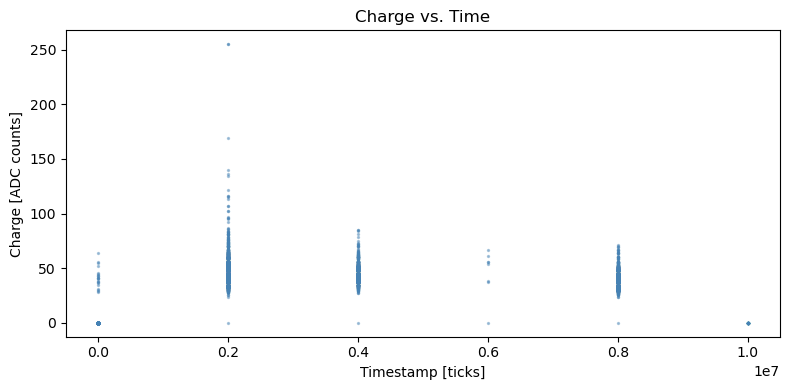

In [12]:
# Day 2 plot 1: charge vs. time. Saves and displays the figure.
import os
from pathlib import Path

import h5py
import matplotlib.pyplot as plt

workdir = Path(os.environ["PSCRATCH"]) / "HPC_intro" / "sim2spec"
output_h5 = workdir / "runs" / "day2_baseline" / "run" / "output.h5"
outplots = workdir / "runs" / "day2_baseline" / "run" / "validation_plots"
outplots.mkdir(parents=True, exist_ok=True)

with h5py.File(output_h5, "r") as f:
    timestamp = f["packets"]["timestamp"][:].astype(float)
    dataword = f["packets"]["dataword"][:].astype(float)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(timestamp, dataword, s=2, alpha=0.4, color="steelblue")
ax.set_xlabel("Timestamp [ticks]")
ax.set_ylabel("Charge [ADC counts]")
ax.set_title("Charge vs. Time")
fig.tight_layout()

plot_path = outplots / "plot_charge_vs_time.png"
fig.savefig(plot_path, dpi=150)
print(f"Saved: {plot_path}")
plt.show()


Saved: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/validation_plots/plot_hits_per_event.png


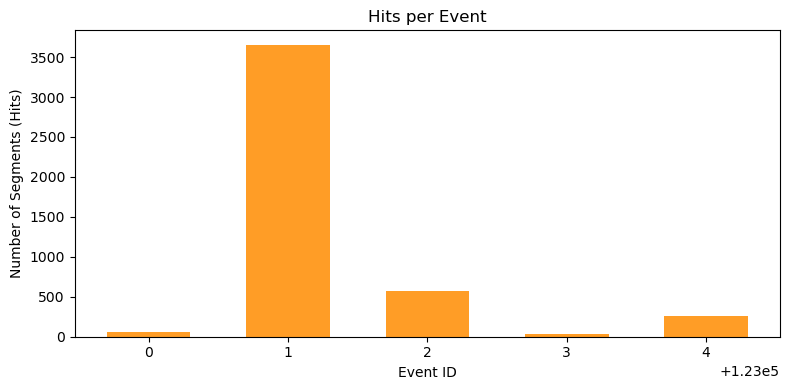

In [13]:
# Day 2 plot 2: hits per event. Saves and displays the figure.
import os
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

workdir = Path(os.environ["PSCRATCH"]) / "HPC_intro" / "sim2spec"
output_h5 = workdir / "runs" / "day2_baseline" / "run" / "output.h5"
outplots = workdir / "runs" / "day2_baseline" / "run" / "validation_plots"
outplots.mkdir(parents=True, exist_ok=True)

with h5py.File(output_h5, "r") as f:
    event_id = f["segments"]["event_id"][:]

unique, counts = np.unique(event_id, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(unique, counts, width=0.6, color="darkorange", alpha=0.85)
ax.set_xlabel("Event ID")
ax.set_ylabel("Number of Segments (Hits)")
ax.set_title("Hits per Event")
fig.tight_layout()

plot_path = outplots / "plot_hits_per_event.png"
fig.savefig(plot_path, dpi=150)
print(f"Saved: {plot_path}")
plt.show()


Saved: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/validation_plots/plot_single_waveform.png


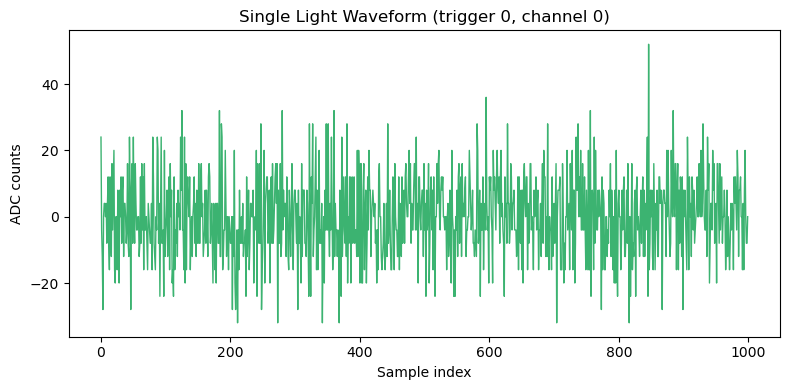

In [14]:
# Day 2 plot 3: single light waveform. Saves and displays the figure.
import os
from pathlib import Path

import h5py
import matplotlib.pyplot as plt

workdir = Path(os.environ["PSCRATCH"]) / "HPC_intro" / "sim2spec"
output_h5 = workdir / "runs" / "day2_baseline" / "run" / "output.h5"
outplots = workdir / "runs" / "day2_baseline" / "run" / "validation_plots"
outplots.mkdir(parents=True, exist_ok=True)

with h5py.File(output_h5, "r") as f:
    waveform = f["light_wvfm"][0, 0, :]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(waveform, color="mediumseagreen", lw=1)
ax.set_xlabel("Sample index")
ax.set_ylabel("ADC counts")
ax.set_title("Single Light Waveform (trigger 0, channel 0)")
fig.tight_layout()

plot_path = outplots / "plot_single_waveform.png"
fig.savefig(plot_path, dpi=150)
print(f"Saved: {plot_path}")
plt.show()

# Project 3 (Day 3): Sweeps and Provenance

Goal: run a small sweep, check that each variant produced metrics, and save a comparison CSV.

Read more: [Project_3_ReadMe.md](../Project_3_ReadMe.md)

What you will run:

- `sim2spec sweep` using `configs/sweep.yaml`
- a manifest and metrics discovery check
- a compact CSV comparison across variants

The sweep runs four variants with random seeds `42`, `1337`, `55555`, and `99999`. Each run records provenance so the output can be traced back to its seed, input, code version, and environment.

Key outputs:

- `$OUTBASE/day3_sweep/000_seed_42/...`
- `$OUTBASE/day3_sweep/001_seed_1337/...`
- `$OUTBASE/day3_sweep/002_seed_55555/...`
- `$OUTBASE/day3_sweep/003_seed_99999/...`
- `$OUTBASE/day3_sweep/comparison.csv`


In [15]:
%%bash
# Day 3 sweep.
export ACCOUNT=${ACCOUNT:-nstaff}   # replace with your NERSC project account
if [[ "$ACCOUNT" == "YOUR_ACCOUNT" ]]; then
    echo "Set ACCOUNT to your NERSC project account before running this GPU cell."
    echo "Example: export ACCOUNT=m1234"
    exit 1
fi

run_day3='export WORKDIR=$PSCRATCH/HPC_intro/sim2spec; cd "$WORKDIR"; export MPLBACKEND=Agg; source setup.sh; source "$venv_name/bin/activate"; export LARNDSIM_DISABLE_CUPY_MEMPOOL=1; hostname; sim2spec sweep --larndsim-dir "$LARNDSIM_DIR" --config 2x2 --input "$INPUT_H5" --outdir "$OUTBASE/day3_sweep" --sweep "$SIM2SPEC_DIR/configs/sweep.yaml" --n-events 3'

if [[ $(hostname) == nid* ]]; then
    bash -lc "$run_day3"
else
    srun -A "$ACCOUNT" -q interactive -C gpu --gpus=1 --ntasks=1 --cpus-per-task=8 -t 00:30:00 bash -lc "$run_day3"
fi


srun: job 54974716 queued and waiting for resources
srun: job 54974716 has been allocated resources


nid001556

  _                      _            _
 | |                    | |          (_)
 | | __ _ _ __ _ __   __| |______ ___ _ _ __ ___
 | |/ _` | '__| '_ \ / _` |______/ __| | '_ ` _ \
 | | (_| | |  | | | | (_| |      \__ \ | | | | | |
 |_|\__,_|_|  |_| |_|\__,_|      |___/_|_| |_| |_|


**************************
LOADING SETTINGS AND INPUT
**************************
Pixel gain files are not provided. Using the default gains.

edep-sim input file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/input/MiniRun5_1E19_RHC.convert2h5.0000123.EDEPSIM.hdf5
larnd-sim output file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/000_seed_42/output.h5

Compression: None
Random seed: 42
Simulation properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/simulation_properties/2x2_NuMI_sim.yaml
Detector properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/detector_properties/2x2.yaml
Pixel layout file: ['/pscratch/sd/m/madan12/HPC_intro/sim2spe

  Simulating event 123001 batches...:  33%|██▎    | 3/9 [00:04<00:08,  1.36s/it]
                                                                                
  Simulating event 123001 batches...: 100%|███████| 9/9 [00:07<00:00,  2.59it/s]


larnd-sim/cli/simulate_pixels.py:1456: UserWarning: More segments per pixel than the set MAX_TRACKS_PER_PIXEL value, 50, or no segments contributed to some pixels.
larnd-sim/cli/simulate_pixels.py:1633: UserWarning: Maximum number of true segments (50) reached in backtracking info, consider increasing MAX_MC_TRUTH_IDS (larndsim/consts/light.py)


Simulating batches...: 100%|██████████████████████| 3/3 [00:11<00:00,  3.86s/it]


...

larnd-sim/cli/simulate_pixels.py:1633: UserWarning: Maximum number of true segments (50) reached in backtracking info, consider increasing MAX_MC_TRUTH_IDS (larndsim/consts/light.py)
Simulating module 3
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 0.62 s


  Simulating event 123000 batches...: 100%|███████| 1/1 [00:01<00:00,  1.86s/it]


larnd-sim/cli/simulate_pixels.py:1633: UserWarning: Maximum number of true segments (50) reached in backtracking info, consider increasing MAX_MC_TRUTH_IDS (larndsim/consts/light.py)


Simulating batches...: 100%|██████████████████████| 3/3 [00:06<00:00,  2.10s/it]


Output saved in: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/003_seed_99999/output.h5
Elapsed time: 86.88 s


In [16]:
%%bash
# Inspect sweep outputs and save comparison CSV.
export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
cd "$WORKDIR"
source setup.sh
source "$venv_name/bin/activate"

ls "$OUTBASE/day3_sweep"
find "$OUTBASE/day3_sweep" -maxdepth 2 -name manifest.json
find "$OUTBASE/day3_sweep" -maxdepth 3 -name metrics.json

python - <<'PY'
import csv, glob, json, os

root = os.environ["OUTBASE"] + "/day3_sweep"
out = root + "/comparison.csv"
rows = []

for mpath in sorted(glob.glob(root + "/*/qa/metrics.json")):
    variant = mpath.split("/")[-3]
    run_dir = os.path.dirname(os.path.dirname(mpath))
    manifest_path = os.path.join(run_dir, "manifest.json")
    metrics = json.load(open(mpath))
    manifest = json.load(open(manifest_path)) if os.path.exists(manifest_path) else {}

    rows.append({
        "variant": variant,
        "config": manifest.get("larndsim", {}).get("config"),
        "seed": manifest.get("sim", {}).get("rand_seed"),
        "n_events": manifest.get("sim", {}).get("n_events"),
        "git_commit": manifest.get("larndsim", {}).get("git", {}).get("commit"),
        "n_packets": metrics.get("n_packets"),
        "adc_mean": metrics.get("adc_mean", metrics.get("adc_mean_guess")),
        "adc_std": metrics.get("adc_std", metrics.get("adc_std_guess")),
        "n_light_wvfm": metrics.get("n_light_wvfm"),
    })

fields = ["variant", "config", "seed", "n_events", "git_commit", "n_packets", "adc_mean", "adc_std", "n_light_wvfm"]
with open(out, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    writer.writerows(rows)

for row in rows:
    print(row)
print(f"Saved: {out}")
PY


000_seed_42
001_seed_1337
002_seed_55555
003_seed_99999
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/000_seed_42/manifest.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/002_seed_55555/manifest.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/003_seed_99999/manifest.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/001_seed_1337/manifest.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/000_seed_42/qa/metrics.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/002_seed_55555/qa/metrics.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/003_seed_99999/qa/metrics.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day3_sweep/001_seed_1337/qa/metrics.json
{'variant': '000_seed_42', 'config': '2x2', 'seed': 42, 'n_events': 3, 'git_commit': '76e43c52b4c467cc72b2128093b5ec9730d22307', 'n_packets': 4993, 'adc_mean': 23.47987182054877, 'adc_std': 25.17762346283151, 'n_light_wvfm': 3}
{'variant': '001_see

# Project 4 (Day 4): Profiling

Goal: profile a baseline run, make one simple comparison run, and record enough information to compare the results.

Read more: [Project_4_ReadMe.md](../Project_4_ReadMe.md)

What you will run:

- a baseline `sim2spec run --profiler nsys`
- `sim2spec profile` to summarize the report
- one comparison run after changing `TPB = 4` to `TPB = 64` in `larnd-sim/cli/simulate_pixels.py`
- a compact wall-time and output-size comparison

Key outputs:

- `$OUTBASE/day4_profile_baseline/run/nsys_report.nsys-rep`
- `$OUTBASE/day4_profile_baseline/run/profile/nsys_stats.json`
- `$OUTBASE/day4_profile_compare/run/nsys_report.nsys-rep`
- `$OUTBASE/day4_profile_compare/run/profile/nsys_stats.json`


In [17]:
%%bash
# Day 4 baseline profile with Nsight Systems.
export ACCOUNT=${ACCOUNT:-nstaff}   # replace with your NERSC project account
if [[ "$ACCOUNT" == "YOUR_ACCOUNT" ]]; then
    echo "Set ACCOUNT to your NERSC project account before running this GPU cell."
    echo "Example: export ACCOUNT=m1234"
    exit 1
fi

run_day4_base='export WORKDIR=$PSCRATCH/HPC_intro/sim2spec; cd "$WORKDIR"; export MPLBACKEND=Agg; source setup.sh; source "$venv_name/bin/activate"; export LARNDSIM_DISABLE_CUPY_MEMPOOL=1; hostname; sim2spec run --larndsim-dir "$LARNDSIM_DIR" --config 2x2 --input "$INPUT_H5" --outdir "$OUTBASE/day4_profile_baseline" --n-events 5 --profiler nsys; sim2spec profile --run-dir "$OUTBASE/day4_profile_baseline/run"'

if [[ $(hostname) == nid* ]]; then
    bash -lc "$run_day4_base"
else
    srun -A "$ACCOUNT" -q interactive -C gpu --gpus=1 --ntasks=1 --cpus-per-task=8 -t 00:30:00 bash -lc "$run_day4_base"
fi


nid001013

  _                      _            _
 | |                    | |          (_)
 | | __ _ _ __ _ __   __| |______ ___ _ _ __ ___
 | |/ _` | '__| '_ \ / _` |______/ __| | '_ ` _ \
 | | (_| | |  | | | | (_| |      \__ \ | | | | | |
 |_|\__,_|_|  |_| |_|\__,_|      |___/_|_| |_| |_|


**************************
LOADING SETTINGS AND INPUT
**************************
Pixel gain files are not provided. Using the default gains.

edep-sim input file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/input/MiniRun5_1E19_RHC.convert2h5.0000123.EDEPSIM.hdf5
larnd-sim output file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_baseline/run/output.h5

Compression: None
Random seed: 321
Simulation properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/simulation_properties/2x2_NuMI_sim.yaml
Detector properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/detector_properties/2x2.yaml
Pixel layout file: ['/pscratch/sd/m/madan12/HPC_intro/sim

  Simulating event 123001 batches...:  33%|██▎    | 3/9 [00:04<00:07,  1.30s/it]
                                                                                
  Simulating event 123001 batches...:  89%|██████▏| 8/9 [00:07<00:00,  2.08it/s]


larnd-sim/cli/simulate_pixels.py:1456: UserWarning: More segments per pixel than the set MAX_TRACKS_PER_PIXEL value, 50, or no segments contributed to some pixels.
larnd-sim/cli/simulate_pixels.py:1633: UserWarning: Maximum number of true segments (50) reached in backtracking info, consider increasing MAX_MC_TRUTH_IDS (larndsim/consts/light.py)


Simulating batches...: 100%|██████████████████████| 5/5 [00:12<00:00,  2.57s/it]


Simulating module 1
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 19.10 s


...

Simulating module 3
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 0.76 s


  Simulating event 123000 batches...: 100%|███████| 1/1 [00:01<00:00,  1.96s/it]


larnd-sim/cli/simulate_pixels.py:1633: UserWarning: Maximum number of true segments (50) reached in backtracking info, consider increasing MAX_MC_TRUTH_IDS (larndsim/consts/light.py)


Simulating batches...: 100%|██████████████████████| 5/5 [00:07<00:00,  1.41s/it]


Output saved in: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_baseline/run/output.h5
Elapsed time: 102.23 s
Generating '/tmp/nsys-report-a454.qdstrm'
[1/1] [========================100%] nsys_report.nsys-rep
Generated:
	/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_baseline/run/nsys_report.nsys-rep
Wrote profile summary: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_baseline/run/profile/nsys_stats.json


### Before Running the Comparison Profile

Make one source change in `larnd-sim` before running the comparison profile. Open:

```text
larnd-sim/cli/simulate_pixels.py
```

Search for this setting:

```python
TPB = 4
```

Change it to:

```python
TPB = 64
```

This changes the CUDA thread-block size. The point is not to guess that one value is always better; the point is to measure a baseline and comparison run with the same `--n-events 5` setting.

For the visual timeline view, download the `.nsys-rep` files from Perlmutter and open them with NVIDIA Nsight Systems on your laptop.

> **Warning for reruns:** `larnd-sim` will not overwrite an existing `output.h5`. If you rerun the comparison profile with the same `--outdir` and see an error like `Output file ... already exists`, remove the old output file first or choose a new output directory:
>
> ```bash
> rm "$OUTBASE/day4_profile_compare/run/output.h5"
> ```


In [18]:
%%bash
# Day 4 comparison profile.
# Before running this cell, search for TPB = 4 in:
#   larnd-sim/cli/simulate_pixels.py
# and change it to TPB = 64.
export ACCOUNT=${ACCOUNT:-nstaff}   # replace with your NERSC project account
if [[ "$ACCOUNT" == "YOUR_ACCOUNT" ]]; then
    echo "Set ACCOUNT to your NERSC project account before running this GPU cell."
    echo "Example: export ACCOUNT=m1234"
    exit 1
fi

run_day4_compare='export WORKDIR=$PSCRATCH/HPC_intro/sim2spec; cd "$WORKDIR"; export MPLBACKEND=Agg; source setup.sh; source "$venv_name/bin/activate"; export LARNDSIM_DISABLE_CUPY_MEMPOOL=1; hostname; sim2spec run --larndsim-dir "$LARNDSIM_DIR" --config 2x2 --input "$INPUT_H5" --outdir "$OUTBASE/day4_profile_compare" --n-events 5 --profiler nsys; sim2spec profile --run-dir "$OUTBASE/day4_profile_compare/run"'

if [[ $(hostname) == nid* ]]; then
    bash -lc "$run_day4_compare"
else
    srun -A "$ACCOUNT" -q interactive -C gpu --gpus=1 --ntasks=1 --cpus-per-task=8 -t 00:30:00 bash -lc "$run_day4_compare"
fi


nid003373

  _                      _            _
 | |                    | |          (_)
 | | __ _ _ __ _ __   __| |______ ___ _ _ __ ___
 | |/ _` | '__| '_ \ / _` |______/ __| | '_ ` _ \
 | | (_| | |  | | | | (_| |      \__ \ | | | | | |
 |_|\__,_|_|  |_| |_|\__,_|      |___/_|_| |_| |_|


**************************
LOADING SETTINGS AND INPUT
**************************
Pixel gain files are not provided. Using the default gains.

edep-sim input file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/input/MiniRun5_1E19_RHC.convert2h5.0000123.EDEPSIM.hdf5
larnd-sim output file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_compare/run/output.h5

Compression: None
Random seed: 321
Simulation properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/simulation_properties/2x2_NuMI_sim.yaml
Detector properties file: /pscratch/sd/m/madan12/HPC_intro/sim2spec/larnd-sim/larndsim/detector_properties/2x2.yaml
Pixel layout file: ['/pscratch/sd/m/madan12/HPC_intro/sim2

  Simulating event 123001 batches...:  33%|██▎    | 3/9 [00:04<00:08,  1.40s/it]
                                                                                
  Simulating event 123001 batches...: 100%|███████| 9/9 [00:07<00:00,  2.43it/s]


larnd-sim/cli/simulate_pixels.py:1456: UserWarning: More segments per pixel than the set MAX_TRACKS_PER_PIXEL value, 50, or no segments contributed to some pixels.
larnd-sim/cli/simulate_pixels.py:1633: UserWarning: Maximum number of true segments (50) reached in backtracking info, consider increasing MAX_MC_TRUTH_IDS (larndsim/consts/light.py)


Simulating batches...: 100%|██████████████████████| 5/5 [00:13<00:00,  2.70s/it]


Simulating module 1
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 19.02 s


...

Simulating module 3
Using LArPix-v2 settings:
{'packet_version': <class 'larpix.packet.packet_v2.Packet_v2'>, 'hdf5_version': '2.4', 'packet_type': 0}
Quenching electrons... 0.00 s
Drifting electrons... 0.00 s
Calculating optical responses... 0.77 s


  Simulating event 123000 batches...: 100%|███████| 1/1 [00:02<00:00,  2.03s/it]


larnd-sim/cli/simulate_pixels.py:1633: UserWarning: Maximum number of true segments (50) reached in backtracking info, consider increasing MAX_MC_TRUTH_IDS (larndsim/consts/light.py)


Simulating batches...: 100%|██████████████████████| 5/5 [00:07<00:00,  1.44s/it]


Output saved in: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_compare/run/output.h5
Elapsed time: 104.57 s
Generating '/tmp/nsys-report-c30d.qdstrm'
[1/1] [========================100%] nsys_report.nsys-rep
Generated:
	/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_compare/run/nsys_report.nsys-rep
Wrote profile summary: /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_compare/run/profile/nsys_stats.json


In [19]:
%%bash
# Compare profiling artifacts and save basic system information.
export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
cd "$WORKDIR"
source setup.sh
source "$venv_name/bin/activate"

cat "$OUTBASE/day4_profile_baseline/run/profile/nsys_stats.json" | head -n 40

python - <<'PY'
import os
base = os.environ["OUTBASE"]
for name in ["day4_profile_baseline", "day4_profile_compare"]:
    run = f"{base}/{name}/run"
    manifest = f"{run}/manifest.json"
    output = f"{run}/output.h5"
    print(f"\n{name}")
    if os.path.exists(manifest) and os.path.exists(output):
        print("  approx_wall_seconds:", round(os.path.getmtime(output) - os.path.getmtime(manifest), 2))
        print("  output_size_MB:", round(os.path.getsize(output) / (1024 * 1024), 2))
    else:
        print("  missing manifest or output.h5")
PY


{
  "nsys_stats_text": "Generating SQLite file /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_baseline/run/nsys_report.sqlite from /pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_baseline/run/nsys_report.nsys-rep\nProcessing [/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day4_profile_baseline/run/nsys_report.sqlite] with [/opt/nvidia/hpc_sdk/Linux_x86_64/25.5/profilers/Nsight_Systems/host-linux-x64/reports/nvtx_sum.py]... \n\n ** NVTX Range Summary (nvtx_sum):\n\n Time (%)   Total Time (ns)   Instances      Avg (ns)           Med (ns)          Min (ns)         Max (ns)        StdDev (ns)      Style                  Range                \n --------  -----------------  ---------  -----------------  -----------------  ---------------  ---------------  ----------------  -------  ------------------------------------\n     78.9  1,447,400,636,041         50   28,948,012,720.8   21,463,272,016.5      351,292,788   70,119,801,504  22,307,775,674.9  PushPop  :get_adc_v

# Day 5: Final Comparison and Summary

Goal: collect the main metrics, validation plots, and profiling artifacts needed for a short final presentation.

Read more: [Project_5_ReadMe.md](../Project_5_ReadMe.md)

What you will run:

- a compact baseline-versus-sweep metric printout
- an artifact discovery command for metrics, manifests, plots, and profiling summaries

Key outputs to discuss:

- Day 2 baseline QA metrics and validation plots
- Day 3 `comparison.csv`
- one Day 3 `manifest.json`
- Day 4 `profile/nsys_stats.json`
- one final slide or short summary explaining what changed and what you learned


In [21]:
%%bash
export WORKDIR=$PSCRATCH/HPC_intro/sim2spec
cd "$WORKDIR"
source setup.sh
source "$venv_name/bin/activate"

python - <<'PY'
import glob, json, os
base = os.environ["OUTBASE"]

baseline = f"{base}/day2_baseline/run/qa/metrics.json"
print("=== BASELINE ===")
if os.path.exists(baseline):
    d = json.load(open(baseline))
    print("baseline", d.get("n_packets"), d.get("adc_mean", d.get("adc_mean_guess")))
else:
    print("missing baseline metrics")

print("=== DAY 3 SWEEP ===")
for path in sorted(glob.glob(f"{base}/day3_sweep/*/qa/metrics.json")):
    d = json.load(open(path))
    print(path.split("/")[-3], d.get("n_packets"), d.get("adc_mean", d.get("adc_mean_guess")))
PY

echo
find "$OUTBASE" -maxdepth 4 \( -name "metrics.json" -o -name "manifest.json" -o -name "*.png" -o -name "nsys_stats.json" \) | sort


=== BASELINE ===
baseline 7004 22.472872644203314
=== DAY 3 SWEEP ===
000_seed_42 4993 23.47987182054877
001_seed_1337 4986 23.48395507420778
002_seed_55555 5162 23.307826423866718
003_seed_99999 5033 23.42837273991655

/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/manifest.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/qa/adc_hist.png
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/qa/light_wvfm0.png
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/qa/metrics.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day1_smoke/run/qa/timestamp_hist.png
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/manifest.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/qa/adc_hist.png
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/qa/light_wvfm0.png
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseline/run/qa/metrics.json
/pscratch/sd/m/madan12/HPC_intro/sim2spec/runs/day2_baseli

## Final Artifact Checklist

- Day 2 baseline `metrics.json`
- Day 2 validation plots
- Day 3 `comparison.csv`
- one Day 3 `manifest.json`
- Day 4 `nsys_stats.json`
- one final slide or short summary explaining what changed and what you learned

Suggested presentation structure:

1. Goal: one sentence describing the simulation workflow.
2. Baseline: one QA metric and one validation plot from Day 2.
3. Sweep: one table or observation from Day 3.
4. Profiling: one measured comparison from Day 4.
5. Takeaway: what changed, what you learned, and one next step.
